In [ ]:
import importlib
from pathlib import Path
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import torch
import transformers
from transformers import AutoTokenizer, AutoModel
import numpy as np
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast

from gender_dataset import GenderDataChunkedDataset, collate_fn, worker_init_fn
from model import GenderChunkedClassifier

: 

In [6]:
tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t')
model = AutoModel.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', trust_remote_code=True)
model_module = importlib.import_module(model.__class__.__module__)
cls = getattr(model_module, 'BertModel')
model = cls.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', add_pooling_layer=False)

/home/jovyan/envs/py3.11_pt2_cu11.8/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [51]:
gender_model = GenderChunkedClassifier(model)

In [8]:
from safetensors.torch import load_model
load_model(gender_model,
           '/home/jovyan/kuratov/dnalm/downstream_tasks/gender_classification/runs/16x3072_bs_128_lr_1e-05_chrY_with_SNPs/run_1/checkpoint-98250/model.safetensors',
           )


(set(), [])

In [48]:
data_path = Path('/home/jovyan/data/downstream_tasks/gender_classification/')
n_chunks = 16
chunk_size = 3072
seed = 142
bs = 32

valid_dataset = GenderDataChunkedDataset(data_path / 'valid.h5', data_path / 'valid.csv',
                                            n_chunks=n_chunks, chunk_size=chunk_size,
                                            force_sampling_from_y=False,
                                            chrY_name='chrY_with_SNPs',
                                            seed=seed+1)

def preprocess_collate_fn(samples):
    batch = collate_fn(samples)

    batch['chunks'] = np.array(batch['chunks'])
    shape = batch['chunks'].shape
    batch['chunks'] = list(batch['chunks'].flatten())

    tokenized_batch = tokenizer(batch['chunks'], padding='longest', max_length=512,
                                truncation=True, return_tensors='pt')

    for k in tokenized_batch:
        tokenized_batch[k] = tokenized_batch[k].reshape(*shape, -1)

    batch['labels'] = torch.Tensor(batch['labels'])

    return {
        'input_ids': tokenized_batch['input_ids'],
        'attention_mask': tokenized_batch['attention_mask'],
        'labels': batch['labels'],
        'sample_ids': batch['sample_id'],
        'full_sample_has_y_chr': batch['full_sample_has_y_chr']
        }

valid_dataloader = DataLoader(valid_dataset, batch_size=bs, collate_fn=preprocess_collate_fn,
                          num_workers=2, pin_memory=True,
                          worker_init_fn=worker_init_fn)

In [49]:
gender_model = gender_model.cuda()

## no chrY upsampling

In [47]:
b.keys()

dict_keys(['input_ids', 'attention_mask', 'labels', 'sample_ids'])

In [20]:
dataloader = valid_dataloader

from tqdm.auto import tqdm
# N = 100000 // bs
N = 100000 // bs

labels = []
probs = []
sample_ids_list = []

for b in tqdm(dataloader, total=N):
    for k in b:
        if k not in ['sample_ids']:
            b[k] = b[k].cuda()

    with autocast(dtype=torch.bfloat16):
        with torch.no_grad():
            outputs = gender_model(b['input_ids'], b['attention_mask'])
            labels += list(b['labels'].cpu().numpy())
            probs += list(outputs['predictions'].float().cpu().numpy())
            sample_ids_list += b['sample_ids']
    N -= 1
    if N <= 0:
        break
labels = np.array(labels)
probs = np.array(probs)
sample_ids_labels = (valid_dataset.labels.loc[list(set(sample_ids_list))]['sex']-1).to_dict()

sample_ids_probs = {}
for i, p in zip(sample_ids_list, probs):
    if i in sample_ids_probs:
        sample_ids_probs[i] += [p]
    else:
        sample_ids_probs[i] = [p]

for k in sample_ids_probs:
    sample_ids_probs[k] = np.array(sample_ids_probs[k])
sample_ids_probs

for k in sample_ids_probs:
    probs = sample_ids_probs[k]
    print(f'{k}: [{sample_ids_labels[k]}] {(probs>0.5).sum() / len(probs):.2f}')

  0%|          | 0/3125 [00:00<?, ?it/s]

/home/jovyan/envs/py3.11_pt2_cu11.8/lib/python3.11/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


NA20528: [0] 0.61
HG04018: [1] 0.69
HG02554: [0] 0.60
HG03807: [1] 0.69
NA12707: [0] 0.60
HG02947: [0] 0.60
HG00405: [1] 0.68
HG01067: [1] 0.68
HG01936: [1] 0.69
HG02489: [0] 0.60


In [21]:
for k in sample_ids_probs:
    probs = sample_ids_probs[k]
    print(f'{k}: [{sample_ids_labels[k]}] {(probs>0.5).sum()}/{len(probs)} = {(probs>0.5).sum() / len(probs):.2f}')

NA20528: [0] 6157/10088 = 0.61
HG04018: [1] 6776/9855 = 0.69
HG02554: [0] 5966/9968 = 0.60
HG03807: [1] 6916/10081 = 0.69
NA12707: [0] 5993/9943 = 0.60
HG02947: [0] 5942/9967 = 0.60
HG00405: [1] 6762/10003 = 0.68
HG01067: [1] 6813/9963 = 0.68
HG01936: [1] 6997/10160 = 0.69
HG02489: [0] 6019/9972 = 0.60


In [22]:
import pickle
pickle.dump({'sample_ids_probs': sample_ids_probs, 'sample_ids_labels': sample_ids_labels}, open('valid_300k_Ysnps.pckl', 'wb'))
d = pickle.load(open('valid_300k_Ysnps.pckl', 'rb'))

sample_ids_probs = d['sample_ids_probs']
sample_ids_labels = d['sample_ids_labels']

sample_ids_sorted = [el[0] for el in sorted(sample_ids_labels.items(), key=lambda x: x[1])]

thr = 0.5039062
thr = 0.5
for k in sample_ids_sorted:
    probs = sample_ids_probs[k]
    print(f"{k}: [{sample_ids_labels[k]}] {(probs>thr).sum()}/{len(probs)} = {(probs>thr).sum() / len(probs):.3f}")

HG02947: [0] 5942/9967 = 0.596
NA20528: [0] 6157/10088 = 0.610
HG02489: [0] 6019/9972 = 0.604
NA12707: [0] 5993/9943 = 0.603
HG02554: [0] 5966/9968 = 0.599
HG03807: [1] 6916/10081 = 0.686
HG04018: [1] 6776/9855 = 0.688
HG01067: [1] 6813/9963 = 0.684
HG00405: [1] 6762/10003 = 0.676
HG01936: [1] 6997/10160 = 0.689


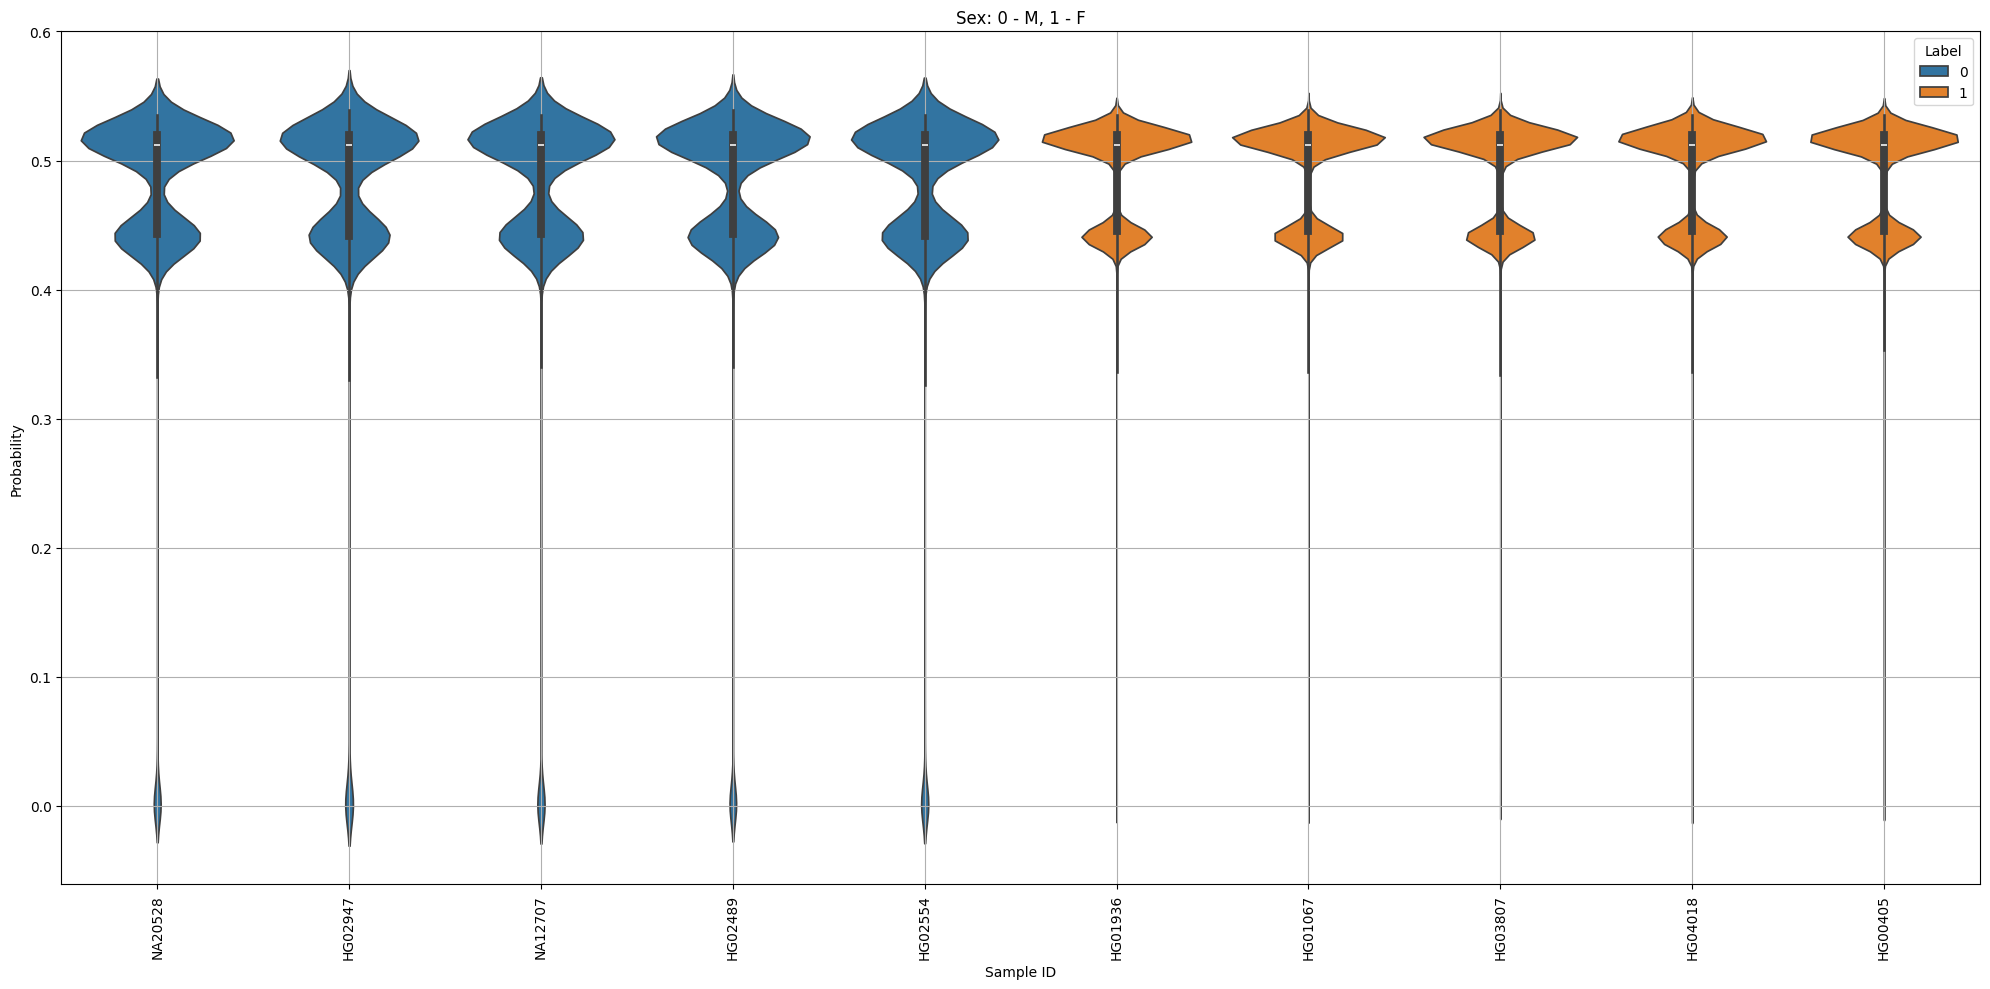

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare DataFrame for plotting
data_list = []
for sample_id, probs in sample_ids_probs.items():
    for prob in probs:
        data_list.append({
            'Sample ID': sample_id,  # Convert to string for consistent key usage
            'Probability': prob[0],
            'Label': sample_ids_labels[sample_id]
        })

df = pd.DataFrame(data_list)

# Sort data by label for plotting
label_order = sorted(df['Label'].unique())
sample_order = df.sort_values(by='Label')['Sample ID'].unique()

# Plotting
plt.figure(figsize=(20, 10))  # Adjusted size for better visibility
ax = sns.violinplot(x='Sample ID', y='Probability', hue='Label', data=df, inner='box',
                    order=sample_order, hue_order=label_order)
# sns.stripplot(x='Sample ID', y='Probability', data=df, color='black', size=1, jitter=True, order=sample_order)
plt.title('Sex: 0 - M, 1 - F')
plt.xticks(rotation=90)
plt.xlabel('Sample ID')
plt.ylabel('Probability')
plt.legend(title='Label')
plt.tight_layout()
plt.grid()
plt.show()

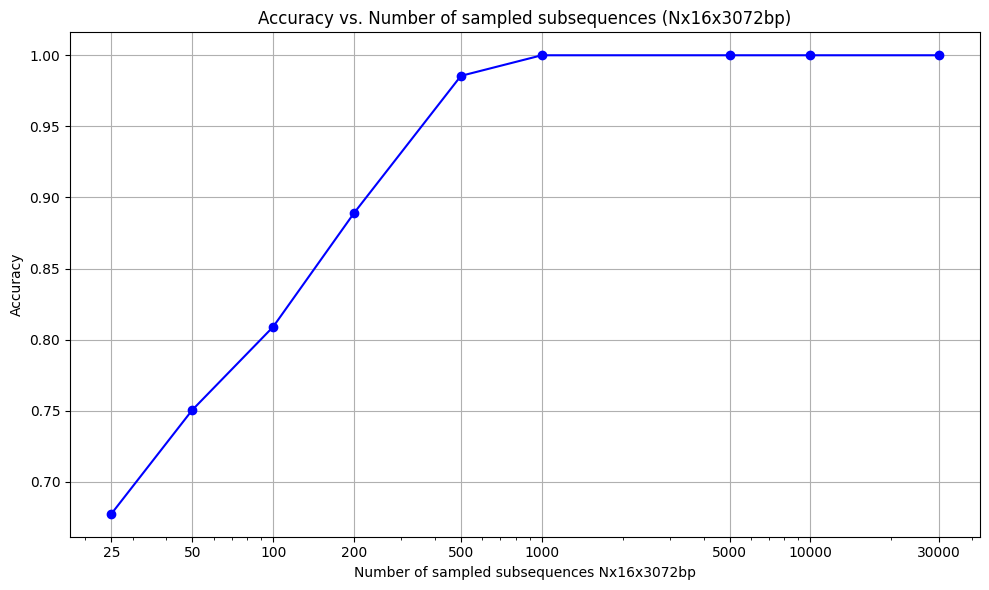

In [36]:
Ns = [25, 50, 100, 200, 500, 1000, 5000, 10000, 30000]
thr = 0.5
accs = []

for N in Ns:
    N_accs = []
    for i in range(200):
        ratios = []
        for k in sample_ids_sorted:
            probs = sample_ids_probs[k]
            probs = np.random.choice(probs[:,0],size=min(N, len(probs)))
            ratios += [(probs>thr).sum() / len(probs)]
            # print(f"{k}: [{sample_ids_labels[k]}] {(probs>thr).sum()}/{len(probs)} = {(probs>thr).sum() / len(probs):.3f}")

        ratios = np.array(ratios)

        acc = 0
        for k, r in zip(sample_ids_sorted, ratios):
            acc += int(int(r > np.median(ratios)) == sample_ids_labels[k])
        acc = acc / len(sample_ids_sorted)
        N_accs += [acc]
    accs += [np.mean(N_accs)]

# Creating the plot
plt.figure(figsize=(10, 6))
plt.plot(Ns, accs, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. Number of sampled subsequences (Nx16x3072bp)')
plt.xlabel('Number of sampled subsequences Nx16x3072bp')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xscale('log')  # Optional: Use logarithmic scale for better visualization if needed
plt.xticks(Ns, labels=[str(n) for n in Ns])  # Ensure that all N values are labeled
plt.tight_layout()
plt.show()